In [ ]:
from nltk.corpus import stopwords
from typing import List, Dict, Literal
from wordcloud import WordCloud, ImageColorGenerator, STOPWORDS
import nltk
import pandas
import re

def load_stop_words() -> List:
    stop_words = open('../stopwords.txt', encoding='utf_8')
    all_content = []
    for i in stop_words.readlines(): all_content.append(i[:-1])
    return all_content

def load_sentilex_pt() -> Dict:
    #Importando o Léxico de Palavras com polaridades
    sentilexpt = open('../SentiLex-lem-PT02.txt', encoding='utf_8')

    #Criando um dicionário de palavras com a respectiva polaridade.
    dic_palavra_polaridade = {}
    for i in sentilexpt.readlines():
        pos_ponto = i.find('.')
        palavra = (i[:pos_ponto])
        pol_pos = i.find('POL')
        polaridade = (i[pol_pos+7:pol_pos+9]).replace(';', '')
        dic_palavra_polaridade[palavra] = polaridade
    return dic_palavra_polaridade

def set_stopwords_workcloud():
    stopwords = set(STOPWORDS)
    
    #Após review das palavras, adicionando alguns termos "sujeira" encontrados nas nuvens
    stopwords.update([
        "pra", "app", "aplicativo", "vc", "pra", "to", "os", "vivo", "vcs", "nao", "pq", "mim", "ai", "ta", "ja", "ter", "fazer", "lá", "deu",
        "dado", "então", "vou", "vai", "veze", "ficar", "tá", "apena", "q", "pois", "nada", "operadora", "sendo", "aí", "dá", "desde", "faz", "pede", "vem",
    ])
    stopwords.update(stopwords)

def remove_stopwords(words) -> List[str]:
    """Remover as Stopwords das palavras tokenizadas"""
    new_words = []
    for word in words:
        if word not in stopwords:
            new_words.append(word)
    return new_words

def to_lowercase(words) -> List[str]:
    """converter todos os caracteres para lowercase"""
    new_words = []
    for word in words:
        new_word = word.lower()
        new_words.append(new_word)
    return new_words

def remove_punctuation(words) -> List[str]:
    """remover pontuação"""
    new_words = []
    for word in words:
        new_word = re.sub(r'[^\w\s]', '', word)
        if new_word != '':
            new_words.append(new_word)
    return new_words

def normalize(words) -> str:
    words = to_lowercase(words)
    words = remove_punctuation(words)
    words = remove_stopwords(words)
    
    return ' '.join(words)

#Criando uma função chamada "Score de Sentimento" para determinar os #sentimentos associados
def Score_sentimento(frase:str, dic_palavra_polaridade:Dict):
    frase = frase.lower()
    l_sentimento = []
    for p in frase.split():
        l_sentimento.append(int(dic_palavra_polaridade.get(p, 0)))
    score = sum(l_sentimento)
    if score > 0:
        return 'Pos {} '.format(score)
    elif score == 0:
        return 'Neu {} '.format(score)
    else:
        
        return 'Neg {}'.format(score)

# Baixar vader, wordnet, punkt, punkt_tab e stopwords
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

LANGUAGE = 'portuguese'

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Matheus\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Matheus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Matheus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Matheus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Matheus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
dic_palavra_polaridade = load_sentilex_pt()

stopwords = stopwords.words(LANGUAGE)
stopwords = list(set(stopwords))
new_stopwords = [
    "pra", "app", "aplicativo", "vc", "pra", "to", "os", "vivo", "vcs", "nao", "pq", "mim", "ai", "ta", "ja", "ter", "fazer", "lá", "deu",
    "dado", "então", "vou", "vai", "veze", "ficar", "tá", "apena", "q", "pois", "nada", "operadora", "sendo", "aí", "dá", "desde", "faz", "pede", "vem",
    'vivo', 'buga'
]
for word in new_stopwords: stopwords.append(word)

data = pandas.read_parquet("../data/raw/br.com.vivo_03_06_2025_BR.parquet")

## Sentilex Approach

In [38]:
data['content'] = data.apply(lambda row: nltk.word_tokenize(row['snippet']), axis=1) # Tokenização dos dados
data['content'] = data.apply(lambda row: normalize(row['content']), axis=1)  # Normalização

#Criando uma função para aplicar um score de sentimento para cada um dos comentários, a partir das palavras positivas e negativas.
data['sentimento'] = data.apply(lambda row: Score_sentimento(row['content'], dic_palavra_polaridade), axis=1)

#Reorganizando o resultado em colunas para posteriormente lançar no modelo
data['Score_Sentimento'] = data['sentimento'].str.slice(-2)
data['Score_Sentimento'] = data['Score_Sentimento'].astype(int)
data['Sent'] = data['sentimento'].str.slice(0,-3)

#Verificando como ficou a distribuição de comentários a partir do Score de Sentimento Criado.
data.groupby('Score_Sentimento').count()

,id,title,avatar,rating,snippet,likes,date,iso_date,response,content,sentimento,Sent
Score_Sentimento,,,,,,,,,,,,
-9,2,2,2,2,2,2,2,2,2,2,2,2
-8,7,7,7,7,7,7,7,7,7,7,7,7
-7,23,23,23,23,23,23,23,23,23,23,23,23
-6,68,68,68,68,68,68,68,68,68,68,68,68
-5,215,215,215,215,215,215,215,215,215,215,215,215
-4,589,589,589,589,589,589,589,589,589,589,589,589
-3,1365,1365,1365,1365,1365,1365,1365,1365,1365,1365,1365,1365
-2,2778,2778,2778,2778,2778,2778,2778,2778,2777,2778,2778,2778
-1,4130,4130,4130,4130,4130,4130,4130,4130,4126,4130,4130,4130


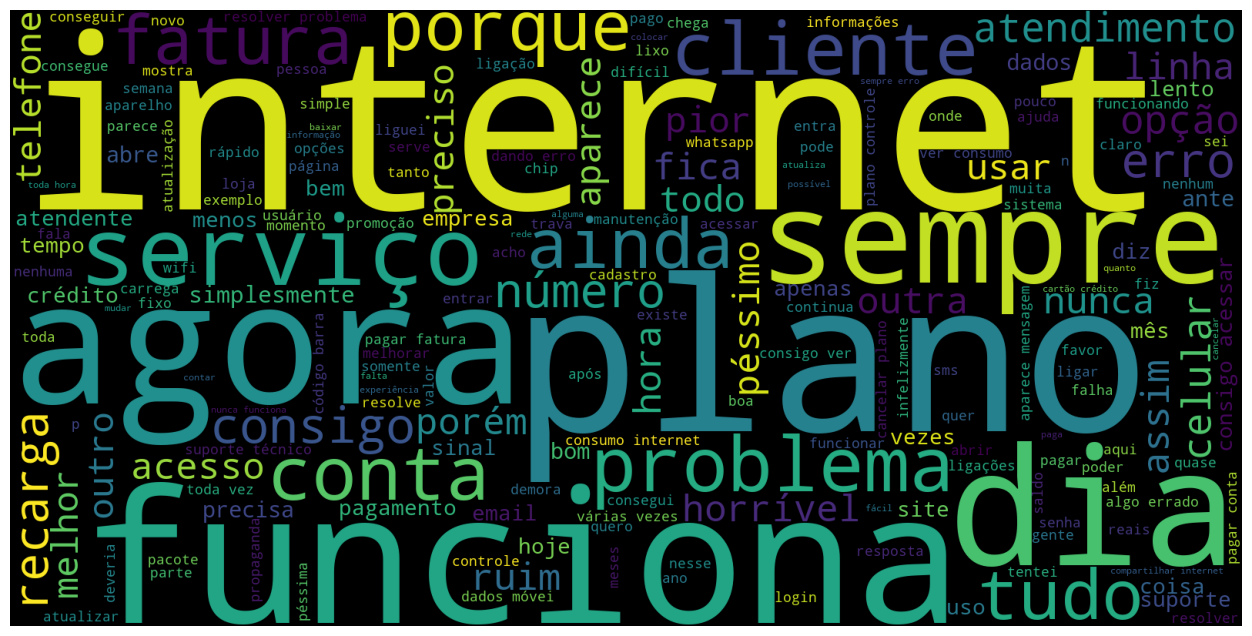

In [59]:
#criando um objeto somente com os comentários
content = data['content']
#juntando todos eles para construir a wordcloud - ela tem que estar todo contido numa string
all_content = "".join(c for c in content)

#montando um novo dicionário de stopwords
def set_stopwords_workcloud():
    stopwords = set(STOPWORDS)
    
    #Após review das palavras, adicionando alguns termos "sujeira" encontrados nas nuvens
    stopwords.update([
        "pra", "app", "aplicativo", "vc", "pra", "to", "os", "vivo", "vcs", "nao", "pq", "mim", "ai", "ta", "ja", "ter", "fazer", "lá", "deu",
        "dado", "então", "vou", "vai", "veze", "ficar", "tá", "apena", "q", "pois", "nada", "operadora", "sendo", "aí", "dá", "desde", "faz", "pede", "vem",
    ])
    stopwords.update(stopwords)
stopwords = set_stopwords_workcloud()

#Criando o objeto wordcloud com as configs necessárias. Cor escolhida = preta, origem dos dados = all_content
wordcloud = WordCloud(stopwords=stopwords,
    background_color='black', width=1600,                            
    height=800).generate(all_content)

import matplotlib.pyplot as plt
#configurando forma de apresentação do gráfico e apresentando no notebook.
fig, ax = plt.subplots(figsize=(16,8))            
ax.imshow(wordcloud, interpolation='bilinear')       
ax.set_axis_off()
plt.imshow(wordcloud)

#### review

In [67]:
data['Score_Sentimento'].min()

np.int64(-9)

In [68]:
def final_sentiment(row):
    if row > 4:
        return 'Positivo'
    if row >=0 & row <=4:
        return 'Neutro'
    else:
        return 'Negativo'
    
data['sentimento_final'] = data.apply(lambda row: final_sentiment(row['Score_Sentimento']), axis=1)
data['sentimento_final'].head(5)

0      Neutro
1    Negativo
2      Neutro
3    Negativo
4    Negativo
Name: sentimento_final, dtype: object

In [69]:
data[data['Score_Sentimento']==0][['Score_Sentimento', 'snippet']]

,Score_Sentimento,snippet
2,0,(Atualização) O app melhorou significativament...
6,0,A atualização do app da Vivo está muito ruim. ...
8,0,Suporte técnico de Internet nunca funciona no ...
25,0,Pq vcs ficam pedindo permissão para gerenciar ...
33,0,"me deram um ""crédito antecipado consumo saldo""..."
...,...,...
179,0,"Intensão boa, mas nao funciona, infelizmente c..."
187,0,"Aplicativo tinha tudo pra ser super útil, até ..."
190,0,"Não resolve nada, mas tudo bem, normal na Vivo..."
194,0,"affs fiz várias recargas, uma no valor de 50 r..."


In [70]:
data.groupby(by=['sentimento_final']).agg({'id':'count'})

,id
sentimento_final,
Negativo,7477
Neutro,8743
Positivo,98


In [71]:
def rank(number):
    idx = [-9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10].index(number)
    if idx == 0: return 0.26315
    else: return idx * 0.26315

data['rank'] = data.apply(lambda row: rank(row['Score_Sentimento']), axis=1)
data['rank'].max()

np.float64(4.99985)

In [72]:
data['rank'].mean()

np.float64(2.272930307022919)

## Leia Approach

In [57]:
from LeIA import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Função para obter o 'compound score'
def get_compound_score(text):
    return analyzer.polarity_scores(text)['compound']

# Função para classificar o sentimento com base no 'compound score'
def get_sentiment_label(compound_score):
    if compound_score > 0.05:   return 'Positivo'
    if compound_score < -0.05:  return 'Negativo'
    return 'Neutro'

def analise(score):
    if score > 0:
        return 'positive'
    return 'negative'

# Aplicando as funções ao DataFrame
data['compound_score'] = data['content'].apply(get_compound_score)
data['sentimento'] = data['compound_score'].apply(get_sentiment_label)

data.groupby(by=['sentimento']).agg({'id':'count'}).reset_index()

,sentimento,id
0,Negativo,8650
1,Neutro,1352
2,Positivo,6316


#### review

In [60]:
data['compound_score'].mean()

np.float64(-0.09823041426645422)

In [45]:
data[data['sentimento']=='Positivo']['content'].head(15)

1     design ótimo parabéns funcionalidade deficient...
2     atualização melhorou significativamente melhor...
11    recebe 5 estrelas porque troquei plano aparece...
12    péssimo todo confuso vezes troco cartão pagame...
14    lento consigo útil tento abrir fatura pagar ap...
18    deveria opção zero estrelas impossível usar pr...
19    péssimo antigamente poderíamos exibir tela tod...
23    gostei forçando barra usar detesto sempre vi t...
31    solicitado crédito antecipado forma mensagem s...
33    deram crédito antecipado consumo saldo autoriz...
35    impressionado qualidade experiência positiva m...
39    ótimo conseguia editar senha ver conectado red...
40    adoro usar apesar instabilidade internet vez e...
41    infelizmente entrega promete funcionalidades s...
44    incrível atende todas expectativas facilidade ...
Name: content, dtype: object

## Vader Approach

In [12]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

# Função para obter o 'compound score'
def get_compound_score(text):
    return analyzer.polarity_scores(text)['compound']

# Função para classificar o sentimento com base no 'compound score'
def get_sentiment_label(compound_score):
    if compound_score >= 0.05:
        return "Positivo"
    elif compound_score <= -0.05:
        return "Negativo"
    else:
        return "Neutro"

# Aplicando as funções ao DataFrame
data['compound_score'] = data['snippet'].apply(get_compound_score)
data['sentimento'] = data['compound_score'].apply(get_sentiment_label)

data.groupby(by=['sentimento']).agg({'id':'count'}).reset_index()

,sentimento,id
0,Negativo,4802
1,Neutro,9219
2,Positivo,2297


#### review

In [40]:
positive = data[data['sentimento']=='Positivo'].drop_duplicates('snippet', keep='first')
positive

,id,title,avatar,rating,snippet,likes,date,iso_date,response,compound_score,sentimento
90,fa04facc-6137-4b87-b878-2e6eddd24730,Warley Cruz,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,"aplicativo super horrível, muito lento e nada ...",8,"March 29, 2025",2025-03-29T21:17:18Z,"{'date': 'March 29, 2025', 'iso_date': '2025-0...",0.6808,Positivo
8,d51b8735-ac6f-4413-ac46-f88941b0448b,Luh Lima,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,"Não sei o que está acontecendo, tem mais de um...",3,"April 20, 2025",2025-04-20T22:25:36Z,"{'date': 'April 20, 2025', 'iso_date': '2025-0...",0.8513,Positivo
78,c333f255-1c1b-4d0d-8750-d6096cf73e89,Sandro Sabino,https://play-lh.googleusercontent.com/a/ACg8oc...,1.0,A página de status portabilidade nunca carrega...,0,"April 02, 2025",2025-04-02T19:07:01Z,"{'date': 'April 02, 2025', 'iso_date': '2025-0...",0.6996,Positivo
88,eb29fb93-f7ac-4c06-b228-db2a25393db4,Luciano Nunes,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,"horrível, pelo amor de Deus!!!!! a internet pe...",0,"March 31, 2025",2025-03-31T10:31:23Z,"{'date': 'March 31, 2025', 'iso_date': '2025-0...",0.7326,Positivo
115,0e6321b7-dbe9-4214-b02d-227ddf3815f4,Luiz Pereira,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,Tem coisas que melhoraram e tem coisas que pio...,0,"March 21, 2025",2025-03-21T08:49:13Z,"{'date': 'March 21, 2025', 'iso_date': '2025-0...",0.7650,Positivo
...,...,...,...,...,...,...,...,...,...,...,...
71,0a2874a3-94d5-4afe-951d-24667548f907,angela nagi,https://play-lh.googleusercontent.com/a/ACg8oc...,1.0,"Olá , primeiramente quero dizer que, o atendim...",0,"July 13, 2021",2021-07-13T18:16:00Z,"{'date': 'July 13, 2021', 'iso_date': '2021-07...",0.6124,Positivo
94,fb518dbf-9f02-4b05-8924-fc0904e0dfe4,adriana barbosa,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,"Fiz portabilidade do meu número para Vivo, por...",1,"September 27, 2024",2024-09-27T09:55:56Z,"{'date': 'September 27, 2024', 'iso_date': '20...",0.6369,Positivo
144,209eca3e-825a-438a-a4b4-d3081ccfafa1,X R,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,"SUPER LENTO, PÉSSIMO, HORRÍVEL, VIVE TRAVANDO!...",1,"September 24, 2021",2021-09-24T22:57:24Z,"{'date': 'September 24, 2021', 'iso_date': '20...",0.7586,Positivo
192,94c2c8ee-6ab8-4bf8-9337-ae58a97184d9,eber vieira,https://play-lh.googleusercontent.com/a-/ALV-U...,1.0,O vivo pelo amor de deus resolve esse problema...,1,"August 10, 2020",2020-08-10T04:35:37Z,"{'date': 'August 10, 2020', 'iso_date': '2020-...",0.7650,Positivo


In [49]:
data[['date', 'snippet']].to_csv('../data/raw/reviews.csv', encoding='utf_8', sep=';')